# Unit13 Example 02 - 非線性模式參數估計與置信區間

本 Notebook 以**十組實驗數據**示範如何使用 `scipy.optimize.curve_fit()` 估計非線性模式 $y = \alpha x^2 + \beta \sin(x) + \gamma x^3$ 中的三個未知參數，並利用返回的協方差矩陣計算各參數的 $95\%$ 置信區間。

## 學習目標
- 理解非線性最小平方法的迭代求解原理（Levenberg-Marquardt 演算法）
- 使用 `scipy.optimize.curve_fit()` 估計非線性模式參數，並取得協方差矩陣 `pcov`
- 由 `pcov` 對角線元素推算標準差，進而計算 $95\%$ 置信區間
- 繪製模式擬合結果圖與殘差分析圖，評估模式適合度

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_02\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit
from scipy.stats import t as t_dist

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題設定：實驗數據與非線性模式

**模式：** $y = \alpha x^2 + \beta \sin(x) + \gamma x^3$

給定以下 10 組 $(x_i, y_i)$ 實驗數據，以參數起始猜測值 $p_0 = [0.5,\ 0.5,\ 0.5]$ 進行迭代求解。

In [3]:
# ========================================
# 實驗數據
# ========================================
xdata = np.array([3.6, 7.7, 9.3, 4.1, 8.6, 2.8, 1.3, 7.9, 10.0, 5.4])
ydata = np.array([16.5, 150.6, 263.1, 24.7, 208.5, 9.9, 2.7, 163.9, 325.0, 54.3])

n  = len(xdata)   # 數據點數
np_ = 3            # 參數個數 (使用 np_ 避免與 numpy 衝突)

print(f"實驗數據 (n = {n} 組):")
print(f"{'i':>4} {'x':>8} {'y':>10}")
print("─" * 26)
for i, (xi, yi) in enumerate(zip(xdata, ydata), 1):
    print(f"{i:>4} {xi:>8.1f} {yi:>10.1f}")

# ========================================
# 定義非線性模式函數
# ========================================
def model_func(x, alpha, beta, gamma):
    """
    非線性模式: y = alpha*x^2 + beta*sin(x) + gamma*x^3
    注意: 雖然此模式在參數上是線性的，此處刻意以 curve_fit 示範非線性求解流程
    """
    return alpha * x**2 + beta * np.sin(x) + gamma * x**3

print("\n✓ 模式函數定義完成: y = alpha*x^2 + beta*sin(x) + gamma*x^3")

實驗數據 (n = 10 組):
   i        x          y
──────────────────────────
   1      3.6       16.5
   2      7.7      150.6
   3      9.3      263.1
   4      4.1       24.7
   5      8.6      208.5
   6      2.8        9.9
   7      1.3        2.7
   8      7.9      163.9
   9     10.0      325.0
  10      5.4       54.3

✓ 模式函數定義完成: y = alpha*x^2 + beta*sin(x) + gamma*x^3


---
### 3. 使用 `scipy.optimize.curve_fit()` 進行參數估計

`curve_fit()` 以 **Levenberg-Marquardt 演算法**迭代求解非線性最小平方問題，返回最佳參數 `popt` 與協方差矩陣 `pcov`。

In [4]:
# ========================================
# 參數起始猜測值
# ========================================
p0 = [0.5, 0.5, 0.5]

# ========================================
# 非線性最小平方法求解
# ========================================
popt, pcov = curve_fit(model_func, xdata, ydata, p0=p0)

alpha_est, beta_est, gamma_est = popt

# ========================================
# 計算誤差平方和
# ========================================
y_model_at_data = model_func(xdata, *popt)
residuals = ydata - y_model_at_data
J = np.sum(residuals**2)

# ========================================
# 列印參數估計結果
# ========================================
print("參數估計結果: y = α*x² + β*sin(x) + γ*x³")
print(f"  α (alpha) = {alpha_est:.4f}")
print(f"  β (beta)  = {beta_est:.4f}")
print(f"  γ (gamma) = {gamma_est:.4f}")
print(f"\n誤差平方和 J = {J:.4f}")

# ========================================
# 各數據點詳細比較
# ========================================
print(f"\n{'各數據點詳細比較:'}")
print(f"{'x':>8} {'y_exp':>10} {'y_model':>10} {'error':>10}")
print("─" * 42)
for xi, yi, ymi, ei in zip(xdata, ydata, y_model_at_data, residuals):
    print(f"{xi:>8.1f} {yi:>10.3f} {ymi:>10.3f} {ei:>10.3f}")

參數估計結果: y = α*x² + β*sin(x) + γ*x³
  α (alpha) = 0.2269
  β (beta)  = 0.3385
  γ (gamma) = 0.3022

誤差平方和 J = 6.2950

各數據點詳細比較:
       x      y_exp    y_model      error
──────────────────────────────────────────
     3.6     16.500     16.888     -0.388
     7.7    150.600    151.729     -1.129
     9.3    263.100    262.704      0.396
     4.1     24.700     24.362      0.338
     8.6    208.500    209.215     -0.715
     2.8      9.900      8.525      1.375
     1.3      2.700      1.373      1.327
     7.9    163.900    163.471      0.429
    10.0    325.000    324.656      0.344
     5.4     54.300     53.933      0.367


---
### 4. 協方差矩陣與 95% 置信區間

由 `curve_fit()` 返回的協方差矩陣 `pcov`，對角線元素的平方根即為各參數的標準差 $\sigma_i = \sqrt{\mathrm{pcov}[i,i]}$；$95\%$ 置信區間為

$$
\hat{p}_i \pm t_{0.975,\,\nu}\,\sigma_i, \quad \nu = n - n_p
$$

其中 $\nu$ 為自由度（本例 $n=10$，$n_p=3$，故 $\nu=7$，$t_{0.975,\,7}=2.3646$），以 t 分佈取代常態分佈的 1.96，在小樣本時更為嚴謹。

In [5]:
# ========================================
# 協方差矩陣
# ========================================
print("協方差矩陣 pcov:")
print(pcov)

# ========================================
# 計算各參數標準差與 95% 置信區間
# ========================================
# 自由度: df = n - n_p = 10 - 3 = 7
df = n - np_

# 95% 信賴水準下 t 分佈臨界值 (雙尾 alpha=0.05)
t_crit = t_dist.ppf(0.975, df)
print(f"\nt 分佈臨界值 (df={df}, 95% CI): t = {t_crit:.4f}")

# 各參數標準差
sigma = np.sqrt(np.diag(pcov))

param_names  = ['α (alpha)', 'β (beta)', 'γ (gamma)']
param_values = [alpha_est, beta_est, gamma_est]

ci_lower = [pv - t_crit * s for pv, s in zip(param_values, sigma)]
ci_upper = [pv + t_crit * s for pv, s in zip(param_values, sigma)]

# ========================================
# 列印置信區間結果
# ========================================
print(f"\n{'='*61}")
print(f"{'參數估計值與 95% 置信區間':^55}")
print(f"{'='*61}")
print(f"{'參數':<12} {'估計值':>8} {'標準差':>10} {'CI 下限':>12} {'CI 上限':>12}")
print("─" * 61)
for name, pv, s, cl, cu in zip(param_names, param_values, sigma, ci_lower, ci_upper):
    print(f"{name:<12} {pv:>8.4f} {s:>10.5f} [{cl:>8.4f}, {cu:>8.4f}]")
print(f"{'='*61}")

協方差矩陣 pcov:
[[ 1.56696001e-03 -2.35858513e-03 -1.72940319e-04]
 [-2.35858513e-03  1.80230893e-01  2.06119998e-04]
 [-1.72940319e-04  2.06119998e-04  1.94581941e-05]]

t 分佈臨界值 (df=7, 95% CI): t = 2.3646

                    參數估計值與 95% 置信區間                    
參數                估計值        標準差        CI 下限        CI 上限
─────────────────────────────────────────────────────────────
α (alpha)      0.2269    0.03958 [  0.1333,   0.3205]
β (beta)       0.3385    0.42454 [ -0.6653,   1.3424]
γ (gamma)      0.3022    0.00441 [  0.2917,   0.3126]


---
### 5. 模式擬合結果圖

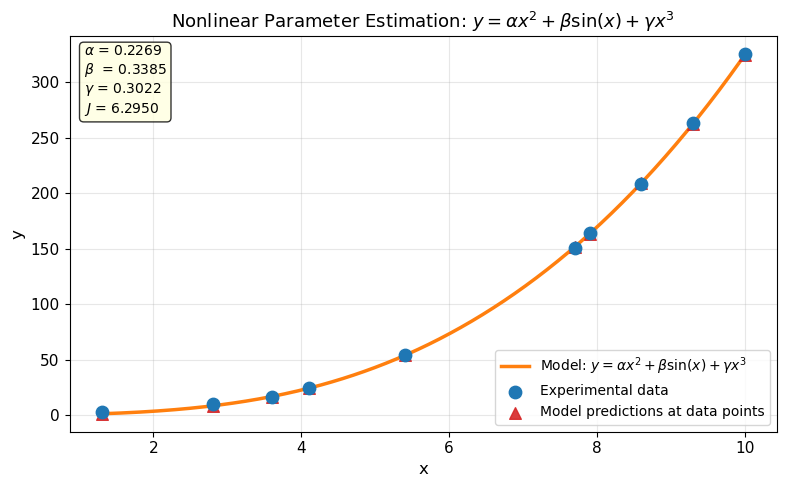

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_02\figs\model_fitting.png


In [6]:
# 生成平滑曲線點
x_fine = np.linspace(xdata.min(), xdata.max(), 300)
y_fine = model_func(x_fine, *popt)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x_fine, y_fine, '-', color='tab:orange', linewidth=2.5,
        label=r'Model: $y = \alpha x^2 + \beta\sin(x) + \gamma x^3$')
ax.scatter(xdata, ydata, s=80, color='tab:blue', zorder=5,
           label='Experimental data')
ax.scatter(xdata, y_model_at_data, marker='^', s=70, color='tab:red',
           zorder=4, alpha=0.9, label='Model predictions at data points')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Nonlinear Parameter Estimation: $y = \alpha x^2 + \beta\sin(x) + \gamma x^3$')
ax.legend(fontsize=10)

# 標註參數值（英文避免中文字型問題）
param_text = (fr"$\alpha$ = {alpha_est:.4f}" + "\n"
              fr"$\beta$  = {beta_est:.4f}"  + "\n"
              fr"$\gamma$ = {gamma_est:.4f}" + "\n"
              fr"$J$ = {J:.4f}")
ax.text(0.02, 0.98, param_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
fig_path = FIG_DIR / 'model_fitting.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path}")

---
### 6. 置信區間視覺化圖

條形圖展示三個參數的估計值與 $95\%$ 置信區間的相對大小，誤差條越短代表數據對該參數的辨識能力越強。

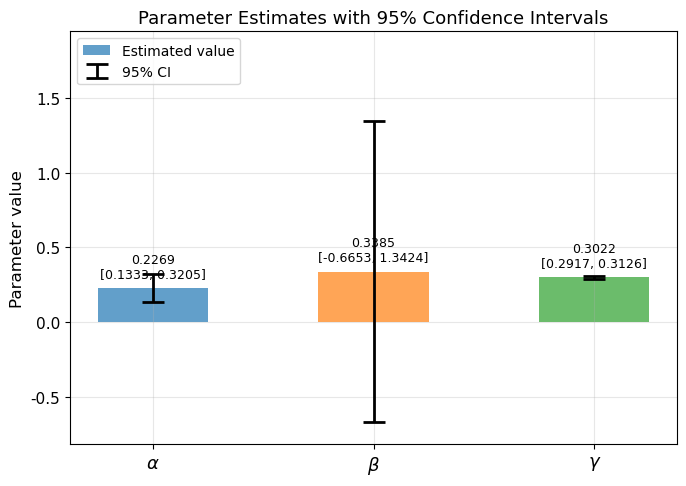

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_02\figs\confidence_interval.png


In [7]:
param_labels = [r'$\alpha$', r'$\beta$', r'$\gamma$']
colors_bar    = ['tab:blue', 'tab:orange', 'tab:green']
ci_half       = [t_crit * s for s in sigma]

fig, ax = plt.subplots(figsize=(7, 5))

x_pos = np.arange(len(param_labels))
bars = ax.bar(x_pos, param_values, color=colors_bar, alpha=0.7, width=0.5,
              label='Estimated value')
ax.errorbar(x_pos, param_values, yerr=ci_half, fmt='none',
            ecolor='black', elinewidth=2, capsize=8, capthick=2,
            label='95% CI')

# 在每個 bar 上方標記數值
for bar, pv, cl, cu in zip(bars, param_values, ci_lower, ci_upper):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(ci_half) * 0.05,
            f'{pv:.4f}\n[{cl:.4f}, {cu:.4f}]',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(param_labels, fontsize=13)
ax.set_ylabel('Parameter value')
ax.set_title('Parameter Estimates with 95% Confidence Intervals')
ax.legend(loc='upper left')
ax.set_ylim(bottom=min(ci_lower) - 0.15,
            top=max(ci_upper) + max(ci_half) * 0.6)

plt.tight_layout()
fig_path_ci = FIG_DIR / 'confidence_interval.png'
plt.savefig(fig_path_ci, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path_ci}")

---
### 7. 殘差分析

良好的模式擬合要求殘差無系統性趨勢且接近常態分佈。左圖為殘差 vs $x$ 圖，右圖為殘差直方圖。

殘差統計:
  殘差最大值:    1.375
  殘差最小值:   -1.129
  殘差均值:      0.234  (理論上應接近 0)
  殘差標準差:    0.758
  RMSE:          0.793


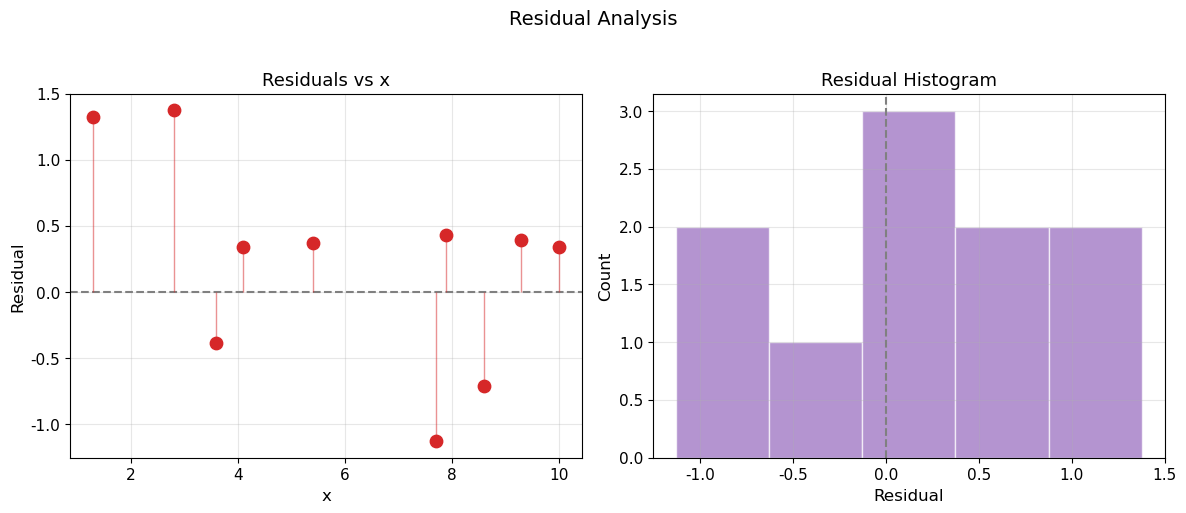

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_02\figs\residual_analysis.png


In [8]:
rmse = np.sqrt(np.mean(residuals**2))

print("殘差統計:")
print(f"  殘差最大值: {residuals.max():>8.3f}")
print(f"  殘差最小值: {residuals.min():>8.3f}")
print(f"  殘差均值:   {residuals.mean():>8.3f}  (理論上應接近 0)")
print(f"  殘差標準差: {residuals.std():>8.3f}")
print(f"  RMSE:       {rmse:>8.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左圖: 殘差 vs x
ax0 = axes[0]
ax0.scatter(xdata, residuals, s=80, color='tab:red', zorder=5)
ax0.axhline(y=0, color='gray', linestyle='--', linewidth=1.5)
for xi, ei in zip(xdata, residuals):
    ax0.vlines(xi, 0, ei, colors='tab:red', alpha=0.5, linewidth=1)
ax0.set_xlabel('x')
ax0.set_ylabel('Residual')
ax0.set_title('Residuals vs x')

# 右圖: 殘差直方圖
ax1 = axes[1]
ax1.hist(residuals, bins=5, color='tab:purple', alpha=0.7, edgecolor='white')
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Residual')
ax1.set_ylabel('Count')
ax1.set_title('Residual Histogram')

plt.suptitle('Residual Analysis', fontsize=14, y=1.02)
plt.tight_layout()
fig_path_res = FIG_DIR / 'residual_analysis.png'
plt.savefig(fig_path_res, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig_path_res}")

---
### 8. 結果總結

| 項目 | 內容 |
|------|------|
| **模式** | $y = \alpha x^2 + \beta \sin(x) + \gamma x^3$ |
| **數據點數** | 10 組 |
| **參數個數** | 3（ $\alpha, \beta, \gamma$ ） |
| **求解方法** | `scipy.optimize.curve_fit()` (Levenberg-Marquardt) |
| **誤差平方和** $J$ | ≈ 6.2950 |
| **RMSE** | ≈ 0.793 |

> **結語：** 本範例示範了以 `curve_fit()` 進行非線性參數估計的完整流程，包含：
> 1. 定義模式函數
> 2. 設定初始猜測值
> 3. 呼叫 `curve_fit()` 取得 `popt` 與 `pcov`
> 4. 由 `pcov` 計算置信區間
> 5. 繪製擬合結果圖與殘差分析圖